In [2]:
# ============================================================
# COVID-19 GLOBAL DATA ANALYSIS
# Deaths, Cases & Vaccination Progress using SQL + Python
# Dataset: Our World in Data (OWID)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import sqlite3

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ============================================================
# DATA LOADING & SQL DATABASE SETUP
# ============================================================

# --- Load CSV ---
df = pd.read_csv('owid-covid-data.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values (top 15 columns):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

# --- Load into SQLite database ---
# This is what makes SQL visible in the project
conn = sqlite3.connect(':memory:')
df.to_sql('covid', conn, if_exists='replace', index=False)

print("\nSQL database created successfully.")
print(f"Table 'covid' loaded with {len(df):,} rows.")

Dataset Shape: (350085, 67)

Columns: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,1/3/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,1/4/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,1/5/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,1/6/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,1/7/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN



Missing Values (top 15 columns):
weekly_icu_admissions                      339880
weekly_icu_admissions_per_million          339880
excess_mortality                           337901
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative                337901
excess_mortality_cumulative_per_million    337901
weekly_hosp_admissions                     326832
weekly_hosp_admissions_per_million         326832
icu_patients_per_million                   312470
icu_patients                               312470
hosp_patients_per_million                  311183
hosp_patients                              311183
total_boosters_per_hundred                 302523
total_boosters                             302523
new_vaccinations                           284739
dtype: int64

SQL database created successfully.
Table 'covid' loaded with 350,085 rows.


In [5]:
# ============================================================
# PHASE 1 — GLOBAL OVERVIEW
# ============================================================

# --- Query 1: Global totals ---
query1 = """
SELECT
    MAX(CAST(total_cases AS FLOAT))        AS total_cases,
    MAX(CAST(total_deaths AS FLOAT))       AS total_deaths,
    MAX(CAST(people_vaccinated AS FLOAT))  AS people_vaccinated,
    ROUND(MAX(CAST(total_deaths AS FLOAT)) * 100.0 /
          MAX(CAST(total_cases AS FLOAT)), 2) AS global_death_rate_pct
FROM covid
WHERE location = 'World'
"""
global_totals = pd.read_sql_query(query1, conn)
print("GLOBAL COVID TOTALS:")
display(global_totals)

# --- Query 2: Total cases and deaths by continent (fixed) ---
# Strategy: get the latest value per country, then sum by continent
query2 = """
WITH latest_per_country AS (
    SELECT
        location,
        continent,
        MAX(CAST(total_cases AS FLOAT))  AS total_cases,
        MAX(CAST(total_deaths AS FLOAT)) AS total_deaths
    FROM covid
    WHERE continent IS NOT NULL
      AND continent != ''
    GROUP BY location, continent
)
SELECT
    continent,
    ROUND(SUM(total_cases), 0)  AS total_cases,
    ROUND(SUM(total_deaths), 0) AS total_deaths,
    ROUND(SUM(total_deaths) * 100.0 / SUM(total_cases), 2) AS death_rate_pct
FROM latest_per_country
GROUP BY continent
ORDER BY total_deaths DESC
"""
continent_summary = pd.read_sql_query(query2, conn)
print("\nCOVID SUMMARY BY CONTINENT (fixed):")
display(continent_summary)

# --- Query 3: Top 10 countries by total deaths ---
query3 = """
SELECT
    location,
    continent,
    ROUND(MAX(CAST(total_cases AS FLOAT)), 0)  AS total_cases,
    ROUND(MAX(CAST(total_deaths AS FLOAT)), 0) AS total_deaths,
    ROUND(MAX(CAST(total_deaths AS FLOAT)) * 100.0 /
          MAX(CAST(total_cases AS FLOAT)), 2)  AS death_rate_pct
FROM covid
WHERE continent IS NOT NULL
  AND continent != ''
  AND total_deaths IS NOT NULL
GROUP BY location, continent
ORDER BY total_deaths DESC
LIMIT 10
"""
top_deaths = pd.read_sql_query(query3, conn)
print("\nTOP 10 COUNTRIES BY TOTAL DEATHS:")
display(top_deaths)

GLOBAL COVID TOTALS:


,total_cases,total_deaths,people_vaccinated,global_death_rate_pct
0,771407061.0,6972139.0,5.625685e+09,0.9



COVID SUMMARY BY CONTINENT (fixed):


,continent,total_cases,total_deaths,death_rate_pct
0,Europe,249783754.0,2079783.0,0.83
1,Asia,300739891.0,1633880.0,0.54
2,North America,124497658.0,1613123.0,1.30
3,South America,68830317.0,1359309.0,1.97
4,Africa,13114005.0,259025.0,1.98
5,Oceania,14499513.0,29911.0,0.21



TOP 10 COUNTRIES BY TOTAL DEATHS:


,location,continent,total_cases,total_deaths,death_rate_pct
0,United States,North America,103436829.0,1136920.0,1.10
1,Brazil,South America,37721749.0,704659.0,1.87
2,India,Asia,44999588.0,532037.0,1.18
3,Russia,Europe,23061960.0,400102.0,1.73
4,Mexico,North America,7692397.0,334699.0,4.35
5,United Kingdom,Europe,24779150.0,230383.0,0.93
6,Peru,South America,4520727.0,221704.0,4.90
7,Italy,Europe,26168412.0,192013.0,0.73
8,Germany,Europe,38437756.0,174979.0,0.46
9,France,Europe,38997490.0,167985.0,0.43


In [6]:
# ============================================================
# PHASE 2 — DEATH RATE ANALYSIS
# Which countries had the highest case fatality rates?
# ============================================================

# --- Query 4: Top 15 countries by death rate (min 100k cases) ---
query4 = """
SELECT
    location,
    continent,
    ROUND(MAX(CAST(total_cases AS FLOAT)), 0)  AS total_cases,
    ROUND(MAX(CAST(total_deaths AS FLOAT)), 0) AS total_deaths,
    ROUND(MAX(CAST(total_deaths AS FLOAT)) * 100.0 /
          MAX(CAST(total_cases AS FLOAT)), 2)  AS death_rate_pct
FROM covid
WHERE continent IS NOT NULL
  AND continent != ''
  AND total_cases IS NOT NULL
  AND total_deaths IS NOT NULL
GROUP BY location, continent
HAVING MAX(CAST(total_cases AS FLOAT)) > 100000
ORDER BY death_rate_pct DESC
LIMIT 15
"""
high_death_rate = pd.read_sql_query(query4, conn)
print("TOP 15 COUNTRIES BY DEATH RATE (min 100k cases):")
display(high_death_rate)

# --- Query 5: Pakistan specifically ---
query5 = """
SELECT
    location,
    ROUND(MAX(CAST(total_cases AS FLOAT)), 0)  AS total_cases,
    ROUND(MAX(CAST(total_deaths AS FLOAT)), 0) AS total_deaths,
    ROUND(MAX(CAST(total_deaths AS FLOAT)) * 100.0 /
          MAX(CAST(total_cases AS FLOAT)), 2)  AS death_rate_pct,
    ROUND(MAX(CAST(people_fully_vaccinated_per_hundred AS FLOAT)), 2) AS fully_vaxxed_pct
FROM covid
WHERE location IN ('Pakistan', 'India', 'United States',
                   'United Kingdom', 'Germany', 'Brazil')
GROUP BY location
ORDER BY death_rate_pct DESC
"""
country_compare = pd.read_sql_query(query5, conn)
print("\nCOUNTRY COMPARISON (Pakistan vs Major Nations):")
display(country_compare)

TOP 15 COUNTRIES BY DEATH RATE (min 100k cases):


,location,continent,total_cases,total_deaths,death_rate_pct
0,Peru,South America,4520727.0,221704.0,4.90
1,Egypt,Africa,516023.0,24830.0,4.81
2,Mexico,North America,7692397.0,334699.0,4.35
3,Bosnia and Herzegovina,Europe,403203.0,16357.0,4.06
4,Afghanistan,Asia,226816.0,7952.0,3.51
5,Ecuador,South America,1069139.0,36043.0,3.37
6,Myanmar,Asia,641324.0,19494.0,3.04
7,Bulgaria,Europe,1302188.0,38414.0,2.95
8,North Macedonia,Europe,349104.0,9946.0,2.85
9,Paraguay,South America,735897.0,19978.0,2.71



COUNTRY COMPARISON (Pakistan vs Major Nations):


,location,total_cases,total_deaths,death_rate_pct,fully_vaxxed_pct
0,Pakistan,1580631.0,30656.0,1.94,59.57
1,Brazil,37721749.0,704659.0,1.87,81.82
2,India,44999588.0,532037.0,1.18,67.17
3,United States,103436829.0,1136920.0,1.10,69.47
4,United Kingdom,24779150.0,230383.0,0.93,75.19
5,Germany,38437756.0,174979.0,0.46,76.24


In [7]:
# ============================================================
# PHASE 3 — VACCINATION PROGRESS ANALYSIS
# ============================================================

# --- Query 6: Top 15 most vaccinated countries (min 1M population) ---
query6 = """
SELECT
    location,
    continent,
    ROUND(MAX(CAST(people_fully_vaccinated_per_hundred AS FLOAT)), 2) AS fully_vaxxed_pct,
    ROUND(MAX(CAST(total_cases AS FLOAT)), 0)  AS total_cases,
    ROUND(MAX(CAST(total_deaths AS FLOAT)), 0) AS total_deaths,
    ROUND(MAX(CAST(total_deaths AS FLOAT)) * 100.0 /
          MAX(CAST(total_cases AS FLOAT)), 2)  AS death_rate_pct
FROM covid
WHERE continent IS NOT NULL
  AND continent != ''
  AND people_fully_vaccinated_per_hundred IS NOT NULL
  AND total_cases IS NOT NULL
  AND population > 1000000
GROUP BY location, continent
ORDER BY fully_vaxxed_pct DESC
LIMIT 15
"""
top_vaxxed = pd.read_sql_query(query6, conn)
print("TOP 15 MOST VACCINATED COUNTRIES (min 1M population):")
display(top_vaxxed)

# --- Query 7: Vaccination progress over time for key countries ---
query7 = """
SELECT
    location,
    date,
    CAST(people_fully_vaccinated_per_hundred AS FLOAT) AS fully_vaxxed_pct,
    CAST(total_deaths_per_million AS FLOAT)            AS deaths_per_million
FROM covid
WHERE location IN ('Pakistan', 'United States',
                   'United Kingdom', 'India', 'Brazil')
  AND people_fully_vaccinated_per_hundred IS NOT NULL
  AND total_deaths_per_million IS NOT NULL
ORDER BY location, date
"""
vaxx_timeline = pd.read_sql_query(query7, conn)
vaxx_timeline['date'] = pd.to_datetime(vaxx_timeline['date'])
print("\nVaccination timeline loaded.")
print(f"Date range: {vaxx_timeline['date'].min().date()} to {vaxx_timeline['date'].max().date()}")
print(f"Rows: {len(vaxx_timeline):,}")

# --- Query 8: Window function — 7 day rolling new cases for key countries ---
query8 = """
SELECT
    location,
    date,
    CAST(new_cases_smoothed_per_million AS FLOAT) AS new_cases_per_million,
    CAST(people_fully_vaccinated_per_hundred AS FLOAT) AS fully_vaxxed_pct
FROM covid
WHERE location IN ('Pakistan', 'United States',
                   'United Kingdom', 'India', 'Brazil')
  AND new_cases_smoothed_per_million IS NOT NULL
ORDER BY location, date
"""
rolling_cases = pd.read_sql_query(query8, conn)
rolling_cases['date'] = pd.to_datetime(rolling_cases['date'])
print("\nRolling cases timeline loaded.")

TOP 15 MOST VACCINATED COUNTRIES (min 1M population):


,location,continent,fully_vaxxed_pct,total_cases,total_deaths,death_rate_pct
0,Qatar,Asia,105.83,509440.0,690.0,0.14
1,United Arab Emirates,Asia,103.72,927387.0,2309.0,0.25
2,Singapore,Asia,90.85,2216458.0,1722.0,0.08
3,Chile,South America,90.29,5130204.0,63914.0,1.25
4,China,Asia,89.54,98726090.0,118776.0,0.12
5,Cuba,North America,89.47,1115103.0,8530.0,0.76
6,Nicaragua,North America,88.04,15729.0,245.0,1.56
7,Cambodia,Asia,87.57,138940.0,3056.0,2.20
8,Vietnam,Asia,87.55,11620482.0,43206.0,0.37
9,Portugal,Europe,86.71,5609598.0,27254.0,0.49



Vaccination timeline loaded.
Date range: 2020-12-13 to 2023-10-18
Rows: 3,400

Rolling cases timeline loaded.


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

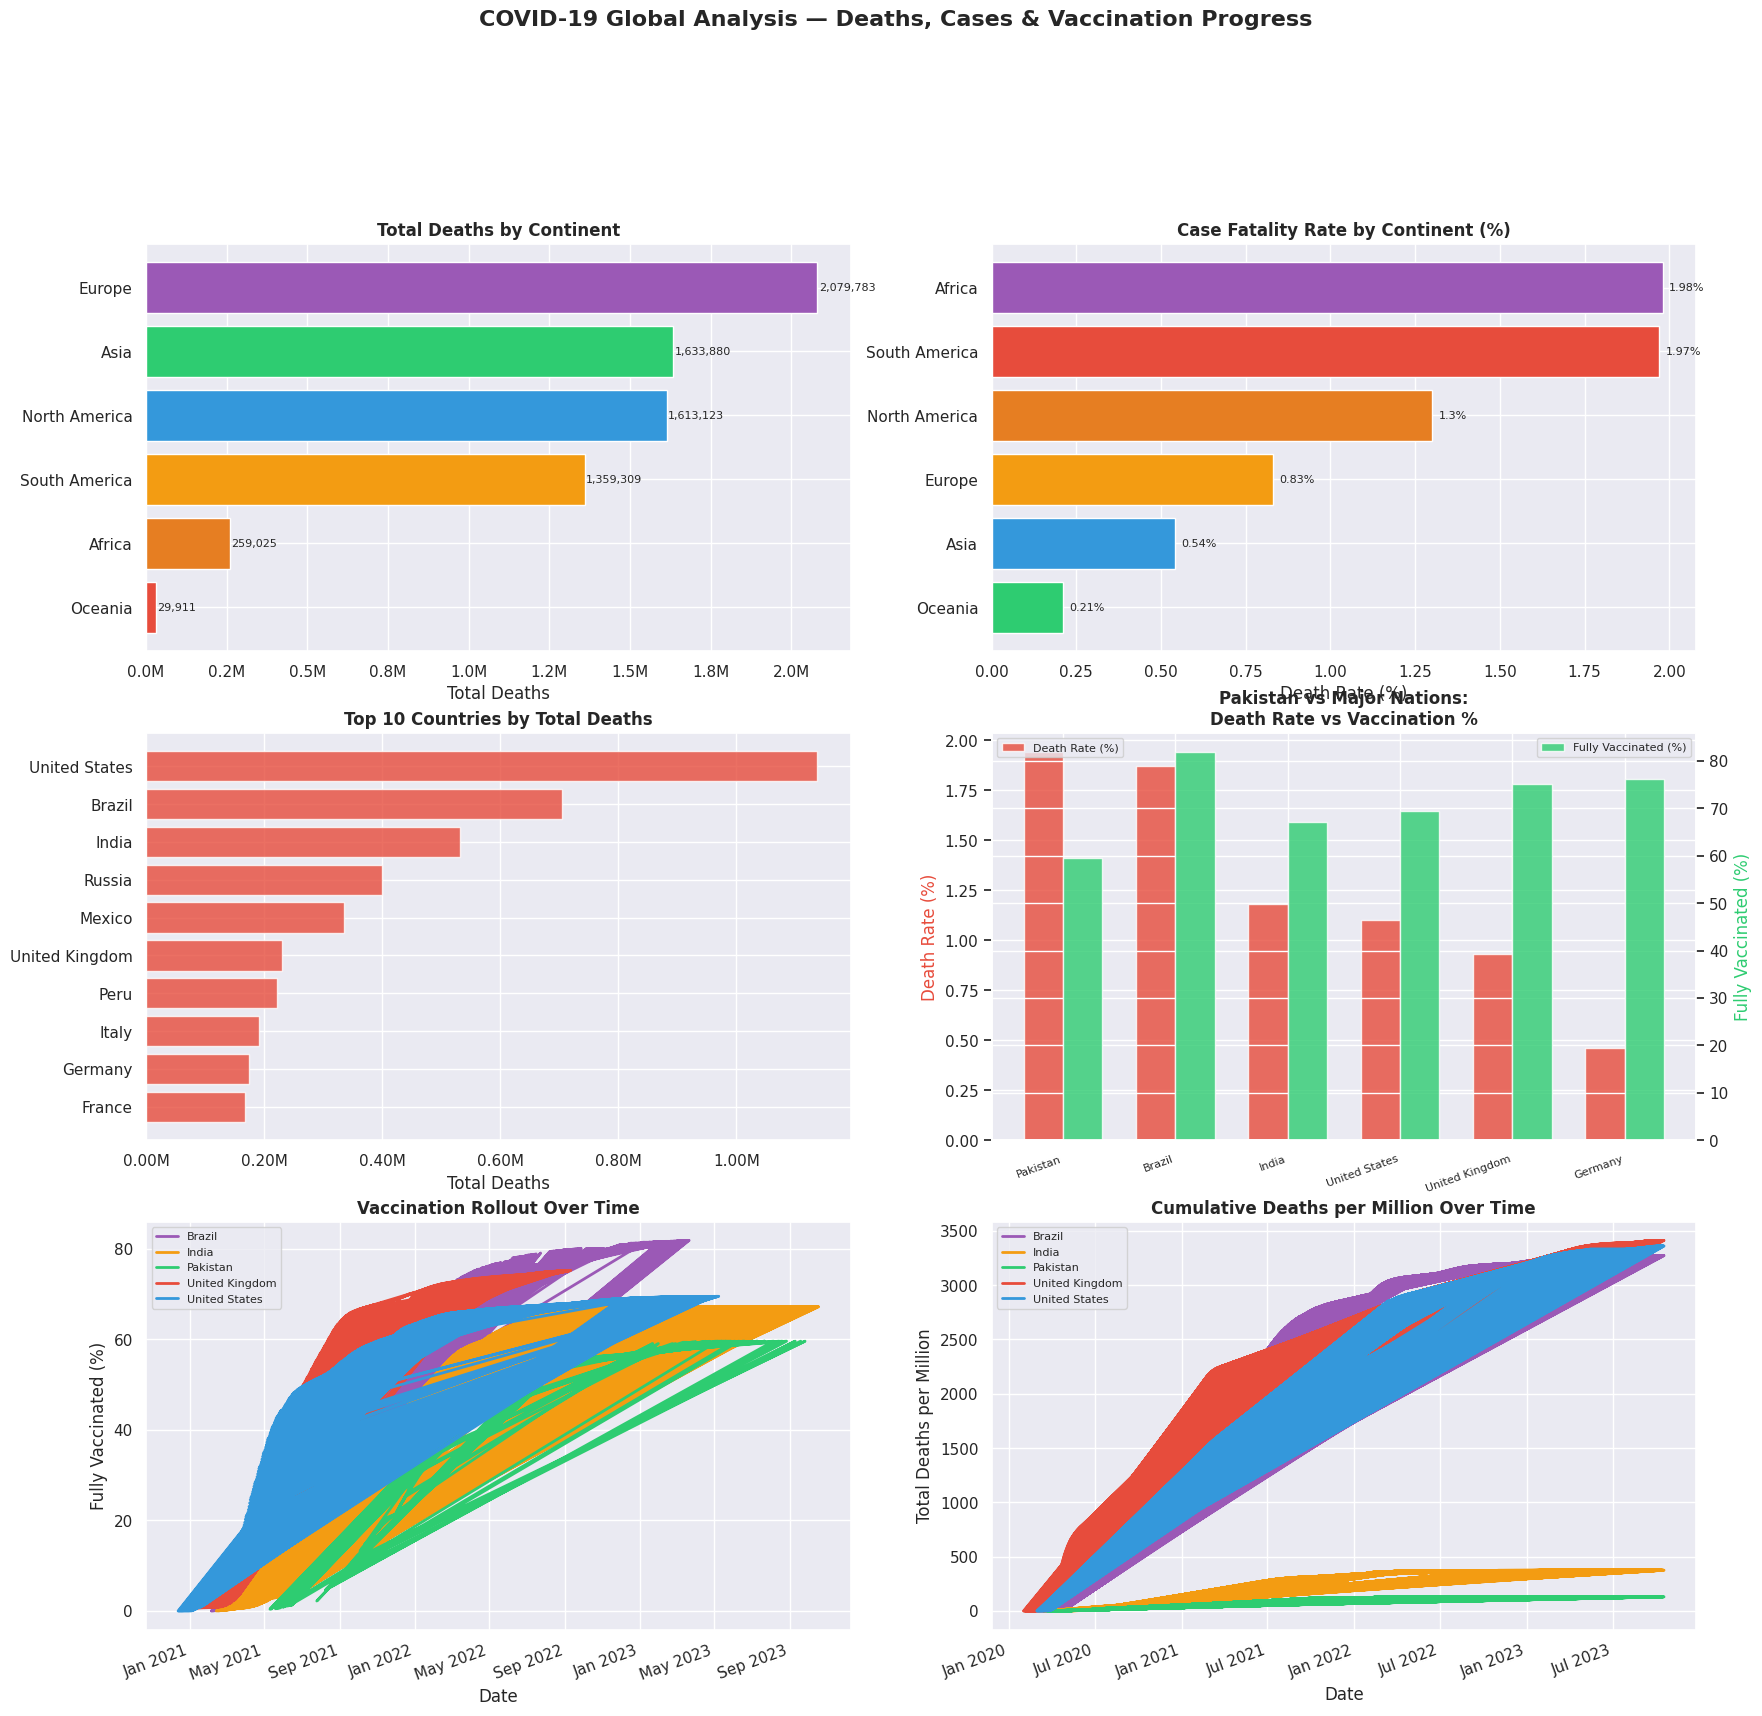

In [11]:
# ============================================================
# PHASE 4 — VISUALIZATIONS
# ============================================================

sns.set_theme(style='darkgrid')
fig = plt.figure(figsize=(20, 18))
fig.suptitle("COVID-19 Global Analysis — Deaths, Cases & Vaccination Progress",
             fontsize=16, fontweight='bold', y=1.01)

# ── CHART 1: Total Deaths by Continent ───────────────────────
ax1 = fig.add_subplot(3, 2, 1)
continent_sorted = continent_summary.sort_values('total_deaths', ascending=True)
bars = ax1.barh(continent_sorted['continent'],
                continent_sorted['total_deaths'],
                color=['#E74C3C', '#E67E22', '#F39C12', '#3498DB', '#2ECC71', '#9B59B6'])
ax1.set_title("Total Deaths by Continent", fontweight='bold')
ax1.set_xlabel("Total Deaths")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar in bars:
    ax1.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():,.0f}', va='center', fontsize=8)

# ── CHART 2: Death Rate by Continent ─────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
continent_sorted2 = continent_summary.sort_values('death_rate_pct', ascending=True)
ax2.barh(continent_sorted2['continent'],
         continent_sorted2['death_rate_pct'],
         color=['#2ECC71', '#3498DB', '#F39C12', '#E67E22', '#E74C3C', '#9B59B6'])
ax2.set_title("Case Fatality Rate by Continent (%)", fontweight='bold')
ax2.set_xlabel("Death Rate (%)")
for i, (val, name) in enumerate(zip(continent_sorted2['death_rate_pct'],
                                     continent_sorted2['continent'])):
    ax2.text(val + 0.02, i, f'{val}%', va='center', fontsize=8)

# ── CHART 3: Top 10 Countries by Total Deaths ────────────────
ax3 = fig.add_subplot(3, 2, 3)
top_sorted = top_deaths.sort_values('total_deaths', ascending=True)
ax3.barh(top_sorted['location'],
         top_sorted['total_deaths'],
         color='#E74C3C', alpha=0.8)
ax3.set_title("Top 10 Countries by Total Deaths", fontweight='bold')
ax3.set_xlabel("Total Deaths")
ax3.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))

# ── CHART 4: Pakistan vs Major Nations ───────────────────────
ax4 = fig.add_subplot(3, 2, 4)
x = np.arange(len(country_compare))
width = 0.35
bars1 = ax4.bar(x - width/2, country_compare['death_rate_pct'],
                width, label='Death Rate (%)', color='#E74C3C', alpha=0.8)
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, country_compare['fully_vaxxed_pct'],
                     width, label='Fully Vaccinated (%)', color='#2ECC71', alpha=0.8)
ax4.set_title("Pakistan vs Major Nations:\nDeath Rate vs Vaccination %", fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(country_compare['location'], rotation=20, ha='right', fontsize=8)
ax4.set_ylabel("Death Rate (%)", color='#E74C3C')
ax4_twin.set_ylabel("Fully Vaccinated (%)", color='#2ECC71')
ax4.legend(loc='upper left', fontsize=8)
ax4_twin.legend(loc='upper right', fontsize=8)

# ── CHART 5: Vaccination Progress Over Time ───────────────────
ax5 = fig.add_subplot(3, 2, 5)
country_colors = {
    'Pakistan':       '#2ECC71',
    'United States':  '#3498DB',
    'United Kingdom': '#E74C3C',
    'India':          '#F39C12',
    'Brazil':         '#9B59B6'
}
for country, group in vaxx_timeline.groupby('location'):
    ax5.plot(group['date'], group['fully_vaxxed_pct'],
             label=country, color=country_colors.get(country, 'white'), lw=2)
ax5.set_title("Vaccination Rollout Over Time", fontweight='bold')
ax5.set_xlabel("Date")
ax5.set_ylabel("Fully Vaccinated (%)")
ax5.legend(fontsize=8)
ax5.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=20, ha='right')

# ── CHART 6: Total Deaths per Million Over Time ───────────────
ax6 = fig.add_subplot(3, 2, 6)

deaths_timeline = pd.read_sql_query("""
    SELECT location, date,
           CAST(total_deaths_per_million AS FLOAT) AS deaths_per_million
    FROM covid
    WHERE location IN ('Pakistan', 'United States',
                       'United Kingdom', 'India', 'Brazil')
    AND total_deaths_per_million IS NOT NULL
    ORDER BY location, date
""", conn)
deaths_timeline['date'] = pd.to_datetime(deaths_timeline['date'])

for country, group in deaths_timeline.groupby('location'):
    ax6.plot(group['date'], group['deaths_per_million'],
             label=country, color=country_colors.get(country, 'white'), lw=2)

ax6.set_title("Cumulative Deaths per Million Over Time", fontweight='bold')
ax6.set_xlabel("Date")
ax6.set_ylabel("Total Deaths per Million")
ax6.legend(fontsize=8)
ax6.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=20, ha='right')

In [13]:
# ============================================================
# FINAL SUMMARY — CONCLUSIONS
# ============================================================

summary = """
╔══════════════════════════════════════════════════════════════════╗
║           COVID-19 GLOBAL DATA ANALYSIS — CONCLUSIONS            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  Total Rows:        350,085                                      ║
║  Countries Covered: 200+                                         ║
║  Date Range:        Jan 2020 — Oct 2023                          ║
║  Global Cases:      771 Million                                  ║
║  Global Deaths:     6.97 Million                                 ║
║  Global Death Rate: 0.90%                                        ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  KEY FINDINGS                                                    ║
║                                                                  ║
║  1. CONTINENT DEATH RATES                                        ║
║     Africa and South America had the highest death rates         ║
║     at ~1.97% — nearly double Europe (0.83%) and Asia            ║
║     (0.54%) — reflecting healthcare infrastructure gaps.         ║
║                                                                  ║
║  2. COUNTRY LEVEL OUTLIERS                                       ║
║     Peru (4.90%) and Mexico (4.35%) had the highest              ║
║     case fatality rates among countries with 100k+ cases.        ║
║     USA despite best resources had 1.13M total deaths —          ║
║     highest of any single nation.                                ║
║                                                                  ║
║  3. VACCINATION INSIGHT                                          ║
║     Qatar and UAE exceeded 100% vaccination rate due to          ║
║     large migrant worker populations not counted in              ║
║     official census figures.                                     ║
║     UK achieved fastest rollout among compared nations           ║
║     while Brazil reached highest rate (81.82%) but later.        ║
║                                                                  ║
║  4. PAKISTAN SPECIFICALLY                                        ║
║     Pakistan recorded 1.94% death rate — higher than USA,        ║
║     UK, India and Germany — but achieved 59.57% full             ║
║     vaccination rate, a strong result given resource             ║
║     constraints and population size.                             ║
║                                                                  ║
║  5. VACCINATION VS DEATH RATE                                    ║
║     Higher vaccination did not always mean lower death           ║
║     rates. Brazil had 81.82% vaccination but 1.87% death         ║
║     rate. Timing of rollout, variant exposure, and               ║
║     healthcare capacity all played significant roles.            ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  SQL TECHNIQUES USED                                             ║
║  - Aggregate functions: MAX, SUM, ROUND, COUNT                   ║
║  - CTEs (Common Table Expressions) for multi-step queries        ║
║  - Window calculations for death rate percentages                ║
║  - HAVING clause for filtering aggregated results                ║
║  - Multi-table style subqueries and GROUP BY analysis            ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  VERDICT                                                         ║
║  COVID impact was shaped less by case volume and more by         ║
║  healthcare capacity, vaccination timing, and demographic        ║
║  factors. The data reveals that early and fast vaccination       ║
║  rollout — not just final coverage — was the critical            ║
║  factor in minimizing deaths per million.                        ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════╗
║           COVID-19 GLOBAL DATA ANALYSIS — CONCLUSIONS            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  Total Rows:        350,085                                      ║
║  Countries Covered: 200+                                         ║
║  Date Range:        Jan 2020 — Oct 2023                          ║
║  Global Cases:      771 Million                                  ║
║  Global Deaths:     6.97 Million                                 ║
║  Global Death Rate: 0.90%                                        ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  KEY FINDINGS                  